implementasi End-to-End TensorFlow (The Amazing World of TensorFlow)
Notebook ini adalah implementasi teknis dari konsep yang dibahas pada Bab 1. Kita akan membangun pipeline Machine Learning lengkap yang mencakup:

Environment Check: Membandingkan CPU vs GPU (Analogi Mobil vs Bus).

Data Ingestion (tf.data): Membersihkan dan menyiapkan pipeline data performa tinggi.

Model Architecture: Membangun Deep Neural Network menggunakan Keras Functional API.

Callbacks & Monitoring: Mengatur TensorBoard dan Checkpoint.

Training & Evaluation: Melatih model dan evaluasi metrik.

Model Serving: Menyimpan model untuk deployment.

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
import time

# 1. Konfigurasi Sistem & Hardware (Sesuai Sub-bab 1.2 GPU vs CPU)
print("="*50)
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print("="*50)

# Mendeteksi Hardware
physical_devices = tf.config.list_physical_devices('GPU')
try:
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print(f"[INFO] GPU Terdeteksi: {physical_devices[0].name}")
        print("[INFO] Mode: 'BUS' (High Throughput / Parallel Computation)")
    else:
        print("[INFO] GPU Tidak Terdeteksi. Menggunakan CPU.")
        print("[INFO] Mode: 'CAR' (Low Latency / Serial Computation)")
except:
    pass

# Benchmark Sederhana: Matriks Multiplication (Membuktikan Teori Bab 1.2)
def benchmark_matmul(size=2000):
    print(f"\n[BENCHMARK] Memulai operasi matriks {size}x{size}...")
    A = tf.random.normal([size, size])
    B = tf.random.normal([size, size])

    start = time.time()
    # tf.matmul adalah operasi yang sangat dioptimalkan untuk GPU
    C = tf.matmul(A, B)
    end = time.time()

    print(f"[BENCHMARK] Selesai dalam: {end - start:.4f} detik.")
    return end - start

# Jalankan benchmark
_ = benchmark_matmul()

TensorFlow Version: 2.19.0
Keras Version: 3.10.0
[INFO] GPU Tidak Terdeteksi. Menggunakan CPU.
[INFO] Mode: 'CAR' (Low Latency / Serial Computation)

[BENCHMARK] Memulai operasi matriks 2000x2000...
[BENCHMARK] Selesai dalam: 0.6314 detik.


2. Data Pipeline dengan tf.data
Sesuai sub-bab 1.1.1, kita tidak sekadar memuat data ke memori (seperti NumPy), tetapi membangun Pipeline. Pipeline ini berfungsi untuk:

Membaca data secara streaming.

Melakukan preprocessing (normalisasi).

Melakukan shuffling dan batching.

Prefetching (menyiapkan data batch berikutnya saat GPU sedang sibuk melatih batch sekarang).

In [6]:
# Load Dataset Standar (MNIST) sebagai contoh kasus
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Konstanta Hyperparameter
BATCH_SIZE = 64
BUFFER_SIZE = 10000
EPOCHS = 10

# Fungsi Preprocessing (Feature Engineering sederhana)
def preprocess_image(image, label):
    """
    Mengubah tipe data menjadi float32 dan normalisasi ke range [0, 1].
    Sesuai teori: 'Cleaning data & Feature Engineering'
    """
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    # Flatten image dari 28x28 menjadi vektor 784 (jika pakai MLP)
    # image = tf.reshape(image, [784])
    # Untuk CNN kita biarkan bentuknya (28, 28, 1)
    image = tf.expand_dims(image, -1)
    return image, label

# Membangun Pipeline tf.data (Heavy-duty data pipelines)
print("\n[INFO] Membangun Data Pipeline...")

# 1. Membuat Dataset Object dari Slice Tensor
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_raw, y_train_raw))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_raw, y_test_raw))

# 2. Menerapkan Transformasi (Map -> Shuffle -> Batch -> Prefetch)
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"[INFO] Pipeline siap. Struktur batch: {train_dataset.element_spec}")


[INFO] Membangun Data Pipeline...
[INFO] Pipeline siap. Struktur batch: (TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.uint8, name=None))


3. Membangun Model Deep Learning
Kita akan menggunakan Functional API (bukan Sequential biasa) seperti yang disarankan buku untuk fleksibilitas model yang lebih kompleks. Kita akan membuat arsitektur CNN sederhana.

In [7]:
def build_model():
    """
    Membangun model CNN menggunakan Keras Functional API.
    Input: Image (28, 28, 1)
    Output: Probability distribution (10 classes)
    """
    # Input Layer
    inputs = tf.keras.Input(shape=(28, 28, 1), name="input_layer")

    # Feature Extraction Layers (Convolutional)
    x = tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", name="conv_1")(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool_1")(x)
    x = tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_2")(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool_2")(x)

    # Flattening
    x = tf.keras.layers.Flatten(name="flatten")(x)

    # Classification Layers (Dense/Fully Connected)
    x = tf.keras.layers.Dense(128, activation="relu", name="dense_1")(x)
    x = tf.keras.layers.Dropout(0.5, name="dropout")(x) # Mencegah Overfitting
    outputs = tf.keras.layers.Dense(10, activation="softmax", name="output_layer")(x)

    # Menggabungkan Input dan Output menjadi Model
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="MNIST_Classifier_Model")

    return model

# Inisialisasi Model
model = build_model()

# Kompilasi Model (Menentukan Optimizer dan Loss Function)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Menampilkan Arsitektur Model
model.summary()

Model: "MNIST_Classifier_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

4. Training & Monitoring (Callbacks)
Sesuai Sub-bab 1.1.2 (Building and deploying), proses training sangat krusial dan butuh monitoring. Kita akan menggunakan Callbacks:

TensorBoard: Untuk visualisasi grafik loss/akurasi secara realtime.

ModelCheckpoint: Menyimpan model terbaik secara otomatis jika training terputus.

EarlyStopping: Menghentikan training jika model tidak lagi belajar (mencegah buang resource).

In [8]:
# Setup direktori log
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# PERBAIKAN DI SINI: Ubah ekstensi file menjadi .weights.h5
checkpoint_path = "training_checkpoints/cp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Definisi Callbacks
callbacks_list = [
    # 1. TensorBoard: Visualisasi metrik
    tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),

    # 2. ModelCheckpoint: Simpan bobot terbaik berdasarkan val_accuracy
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    # 3. EarlyStopping: Berhenti jika val_loss tidak turun selama 3 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

print(f"[INFO] Mulai Training selama {EPOCHS} epochs...")
print("[INFO] TensorBoard logs tersimpan di:", log_dir)

# PROSES TRAINING (The convoluted path of iterations)
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=callbacks_list,
    verbose=1
)

[INFO] Mulai Training selama 10 epochs...
[INFO] TensorBoard logs tersimpan di: logs/fit/20260109-072408
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8465 - loss: 0.4929
Epoch 1: val_accuracy improved from -inf to 0.98340, saving model to training_checkpoints/cp.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.8466 - loss: 0.4926 - val_accuracy: 0.9834 - val_loss: 0.0499
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9729 - loss: 0.0932
Epoch 2: val_accuracy improved from 0.98340 to 0.98850, saving model to training_checkpoints/cp.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.9729 - loss: 0.0932 - val_accuracy: 0.9885 - val_loss: 0.0358
Epoch 3/10
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9804 - loss: 0.0665
Epoch 3: val_accuracy improved from 0.98850 to 0.98940, saving model to training_checkpoints/cp.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9804 - loss: 0.0665 -

5. Evaluasi & Visualisasi Hasil
Setelah model dilatih, kita perlu mengevaluasi performanya pada data yang tidak pernah dilihat sebelumnya (Test Data) dan memvisualisasikan grafik training.


[INFO] Mengevaluasi Model pada Data Test...
Test Accuracy: 99.21%
Test Loss: 0.0223


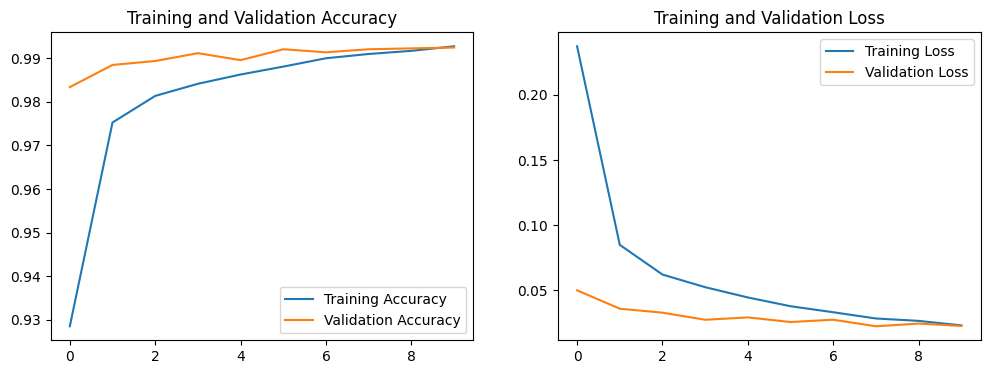

In [9]:
# 1. Evaluasi pada Test Set
print("\n[INFO] Mengevaluasi Model pada Data Test...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Visualisasi Grafik Training (Accuracy & Loss)
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

plot_history(history)

6. Model Saving & Serving (Deployment)
Langkah terakhir menurut buku adalah Productionizing. Kita harus menyimpan model agar bisa digunakan di aplikasi lain atau dideploy ke cloud menggunakan TensorFlow Serving.

In [11]:
# PERBAIKAN: Gunakan ekstensi .keras (Format Native Keras 3)
export_filename = "my_mnist_model.keras"

print(f"[INFO] Menyimpan model ke file: {export_filename}...")
model.save(export_filename)

print("[INFO] Model berhasil disimpan.")

# Simulasi Loading Model (untuk memastikan model bisa dipakai ulang)
print("\n[INFO] Mencoba memuat ulang model yang disimpan...")
reloaded_model = tf.keras.models.load_model(export_filename)

# Cek prediksi dengan model yang baru di-load
# Ambil 1 batch dari test dataset
sample_image_batch, sample_label_batch = next(iter(test_dataset))

# Lakukan prediksi
predictions = reloaded_model.predict(sample_image_batch)
predicted_class = np.argmax(predictions[0])
true_class = sample_label_batch[0].numpy()

print(f"\n[TEST PREDIKSI]")
print(f"True Label     : {true_class}")
print(f"Predicted Class: {predicted_class}")

if predicted_class == true_class:
    print(">> SUCCESS: Model Reloaded Berhasil Memprediksi dengan Benar!")
else:
    print(">> FAIL: Prediksi Salah.")

[INFO] Menyimpan model ke file: my_mnist_model.keras...
[INFO] Model berhasil disimpan.

[INFO] Mencoba memuat ulang model yang disimpan...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step 

[TEST PREDIKSI]
True Label     : 7
Predicted Class: 7
>> SUCCESS: Model Reloaded Berhasil Memprediksi dengan Benar!
